# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
#%pip install --upgrade plotly

## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print("df_hh_income Shape:", df_hh_income.shape)
print("df_pct_poverty Shape:", df_pct_poverty.shape)
print("df_pct_completed_hs Shape:", df_pct_completed_hs.shape)
print("df_share_race_city Shape:", df_share_race_city.shape)
print("df_fatalities Shape:", df_fatalities.shape)

df_hh_income Shape: (29322, 3)
df_pct_poverty Shape: (29329, 3)
df_pct_completed_hs Shape: (29329, 3)
df_share_race_city Shape: (29268, 7)
df_fatalities Shape: (2535, 14)


In [6]:
print("\nFatalities Info:")
df_fatalities.info()


Fatalities Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   object 
 2   date                     2535 non-null   object 
 3   manner_of_death          2535 non-null   object 
 4   armed                    2526 non-null   object 
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   object 
 7   race                     2340 non-null   object 
 8   city                     2535 non-null   object 
 9   state                    2535 non-null   object 
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   object 
 12  flee                     2470 non-null   object 
 13  body_camera              2535 non-null   bool   
dtypes: boo

In [7]:
print("Missing values in df_fatalities:\n", df_fatalities.isnull().sum())
print("\nMissing values in df_pct_poverty:\n", df_pct_poverty.isnull().sum())
print("\nMissing values in df_pct_completed_hs:\n", df_pct_completed_hs.isnull().sum())
print("\nMissing values in df_share_race_city:\n", df_share_race_city.isnull().sum())
print("\nMissing values in df_hh_income:\n", df_hh_income.isnull().sum())

Missing values in df_fatalities:
 id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

Missing values in df_pct_poverty:
 Geographic Area    0
City               0
poverty_rate       0
dtype: int64

Missing values in df_pct_completed_hs:
 Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

Missing values in df_share_race_city:
 Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

Missing values in df_hh_income:


In [8]:
print("Duplicates in df_fatalities:", df_fatalities.duplicated().sum())
print("Duplicates in df_pct_poverty:", df_pct_poverty.duplicated().sum())
print("Duplicates in df_pct_completed_hs:", df_pct_completed_hs.duplicated().sum())
print("Duplicates in df_share_race_city:", df_share_race_city.duplicated().sum())
print("Duplicates in df_hh_income:", df_hh_income.duplicated().sum())

Duplicates in df_fatalities: 0
Duplicates in df_pct_poverty: 0
Duplicates in df_pct_completed_hs: 0
Duplicates in df_share_race_city: 0
Duplicates in df_hh_income: 0


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [9]:
df_pct_poverty.poverty_rate = pd.to_numeric(df_pct_poverty.poverty_rate, errors='coerce')
df_pct_poverty.dropna(inplace=True)

In [10]:
df_pct_completed_hs.percent_completed_hs = pd.to_numeric(df_pct_completed_hs.percent_completed_hs, errors='coerce')
df_pct_completed_hs.dropna(inplace=True)

In [11]:
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')
df_hh_income.dropna(inplace=True)

In [12]:
df_fatalities.dropna(subset=['age'], inplace=True)

In [13]:
print("df_pct_poverty nulls:", df_pct_poverty.isnull().sum().sum())
print("df_pct_completed_hs nulls:", df_pct_completed_hs.isnull().sum().sum())
print("df_hh_income nulls:", df_hh_income.isnull().sum().sum())
print("df_fatalities 'age' nulls:", df_fatalities['age'].isnull().sum())

df_pct_poverty nulls: 0
df_pct_completed_hs nulls: 0
df_hh_income nulls: 0
df_fatalities 'age' nulls: 0


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [14]:
poverty_by_state = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False)
poverty_by_state.head()

,poverty_rate
Geographic Area,
MS,26.88
AZ,25.67
GA,23.78
NM,23.08
AR,22.96


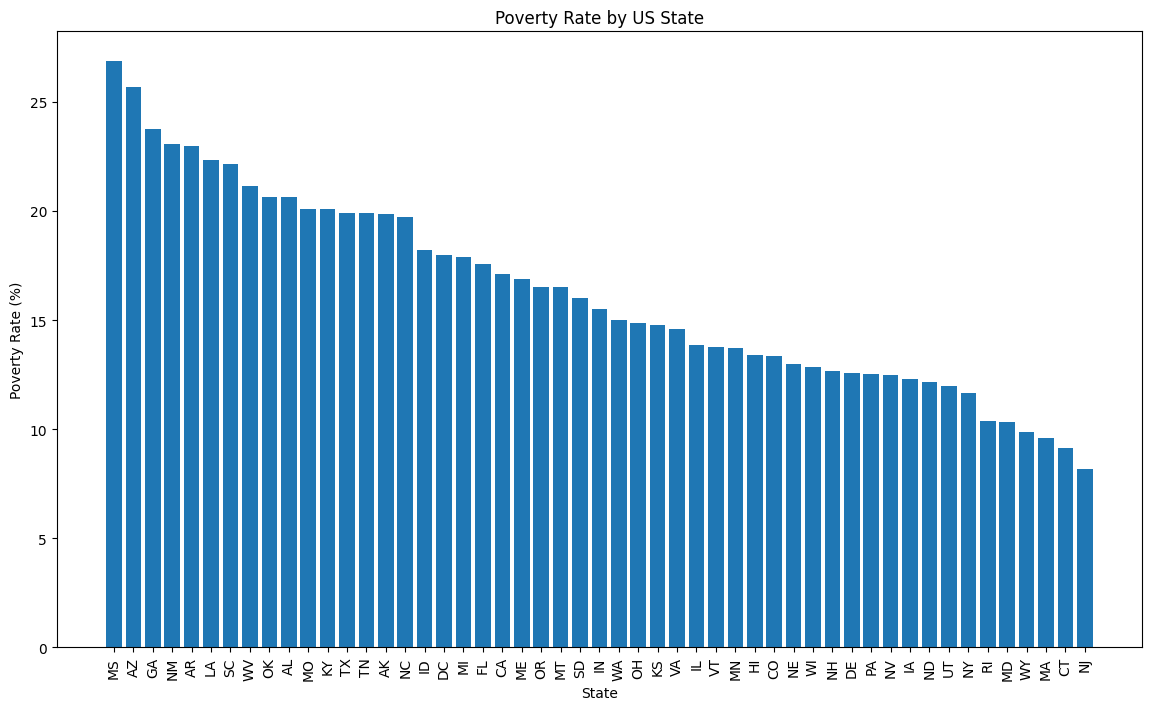

In [15]:
plt.figure(figsize=(14, 8))
plt.bar(poverty_by_state.index, poverty_by_state.values)
plt.xticks(rotation=90)
plt.ylabel('Poverty Rate (%)')
plt.xlabel('State')
plt.title('Poverty Rate by US State')
plt.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [16]:
hs_grad_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values()

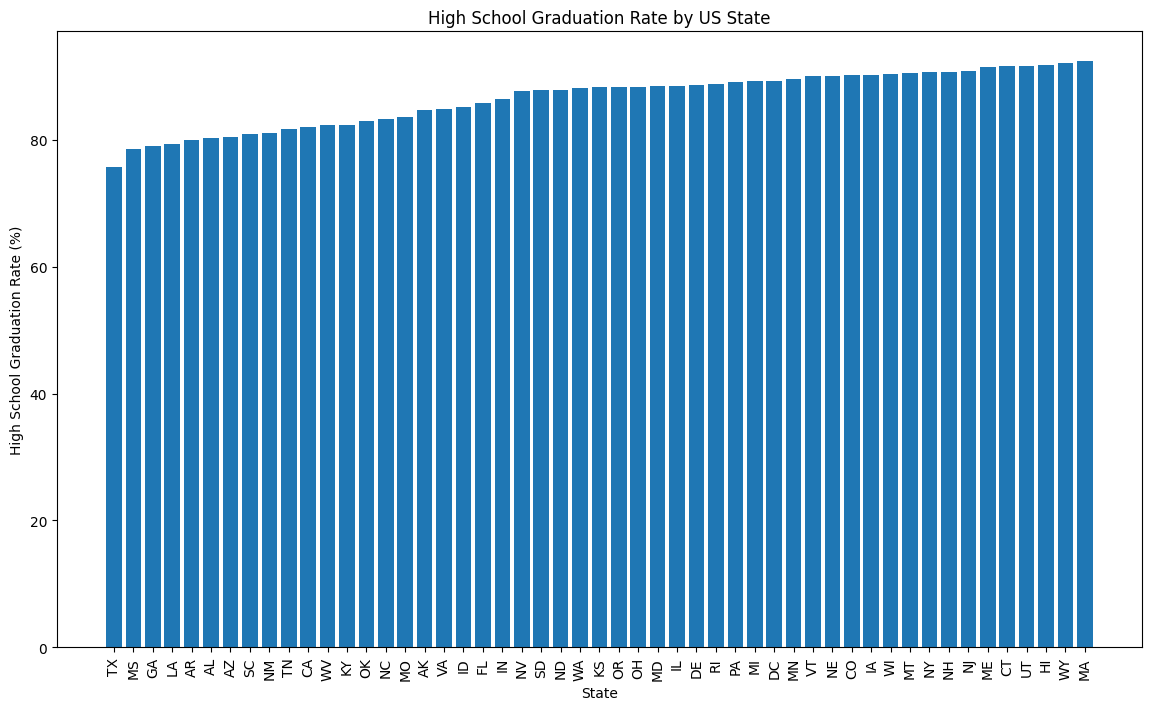

In [17]:
plt.figure(figsize=(14, 8))
plt.bar(hs_grad_by_state.index, hs_grad_by_state.values)
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('High School Graduation Rate (%)')
plt.title('High School Graduation Rate by US State')
plt.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

/tmp/ipython-input-3245142202.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_state_stats.index, rotation=90)


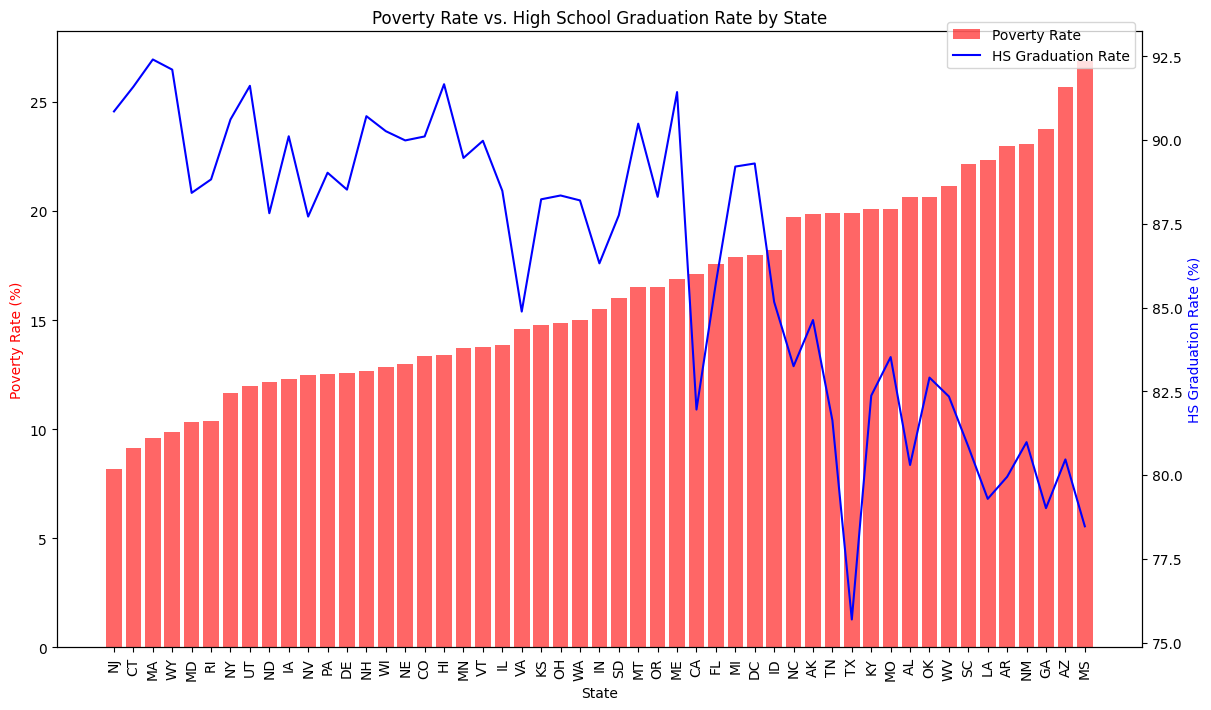

In [18]:
df_state_stats = pd.merge(poverty_by_state, hs_grad_by_state, on='Geographic Area')
df_state_stats.sort_values('poverty_rate', inplace=True)

fig, ax1 = plt.subplots(figsize=(14, 8))

ax2 = ax1.twinx()
ax1.bar(df_state_stats.index, df_state_stats['poverty_rate'], color='r', alpha=0.6, label='Poverty Rate')
ax2.plot(df_state_stats.index, df_state_stats['percent_completed_hs'], color='b', label='HS Graduation Rate')

ax1.set_xlabel('State')
ax1.set_ylabel('Poverty Rate (%)', color='r')
ax2.set_ylabel('HS Graduation Rate (%)', color='b')
ax1.set_xticklabels(df_state_stats.index, rotation=90)
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.9))
plt.title('Poverty Rate vs. High School Graduation Rate by State')
plt.show()

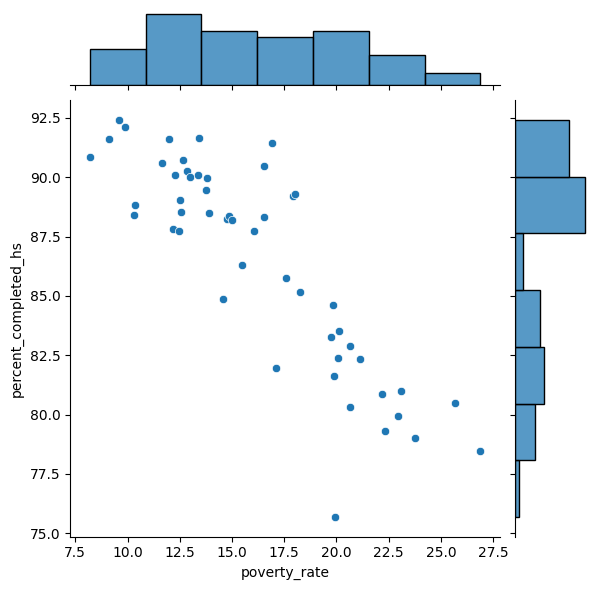

In [19]:
sns.jointplot(x='poverty_rate', y='percent_completed_hs', data=df_state_stats, kind='scatter')
plt.show()

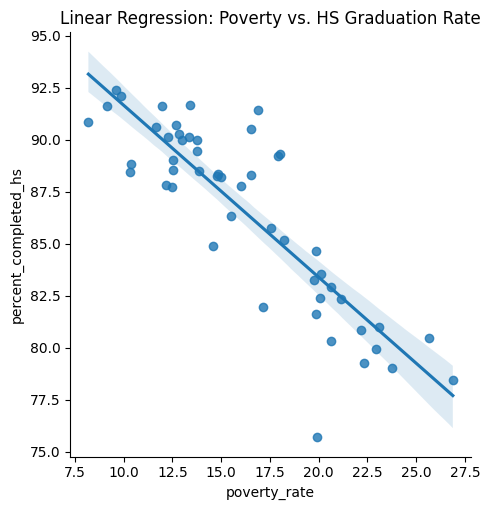

In [20]:
sns.lmplot(x='poverty_rate', y='percent_completed_hs', data=df_state_stats)
plt.title('Linear Regression: Poverty vs. HS Graduation Rate')
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [21]:
race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

df_share_race_city.dropna(inplace=True)

race_by_state = df_share_race_city.groupby('Geographic area')[race_cols].mean()

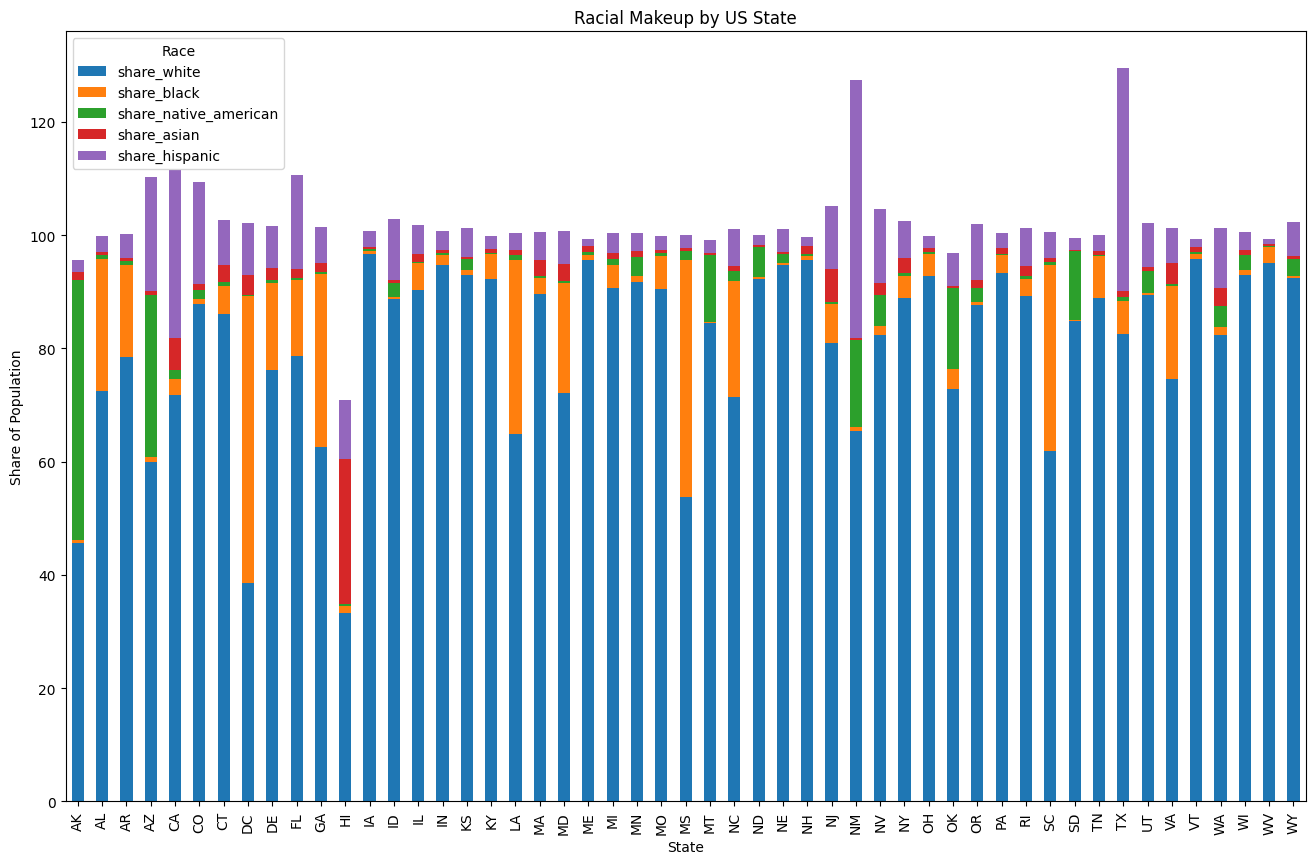

In [22]:
race_by_state.plot(kind='bar', stacked=True, figsize=(16, 10))
plt.title('Racial Makeup by US State')
plt.xlabel('State')
plt.ylabel('Share of Population')
plt.legend(title='Race')
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

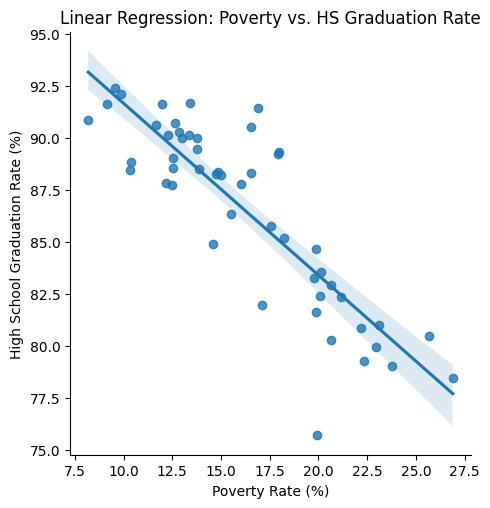

In [23]:
sns.lmplot(x='poverty_rate', y='percent_completed_hs', data=df_state_stats)
plt.title('Linear Regression: Poverty vs. HS Graduation Rate')
plt.xlabel("Poverty Rate (%)")
plt.ylabel("High School Graduation Rate (%)")
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

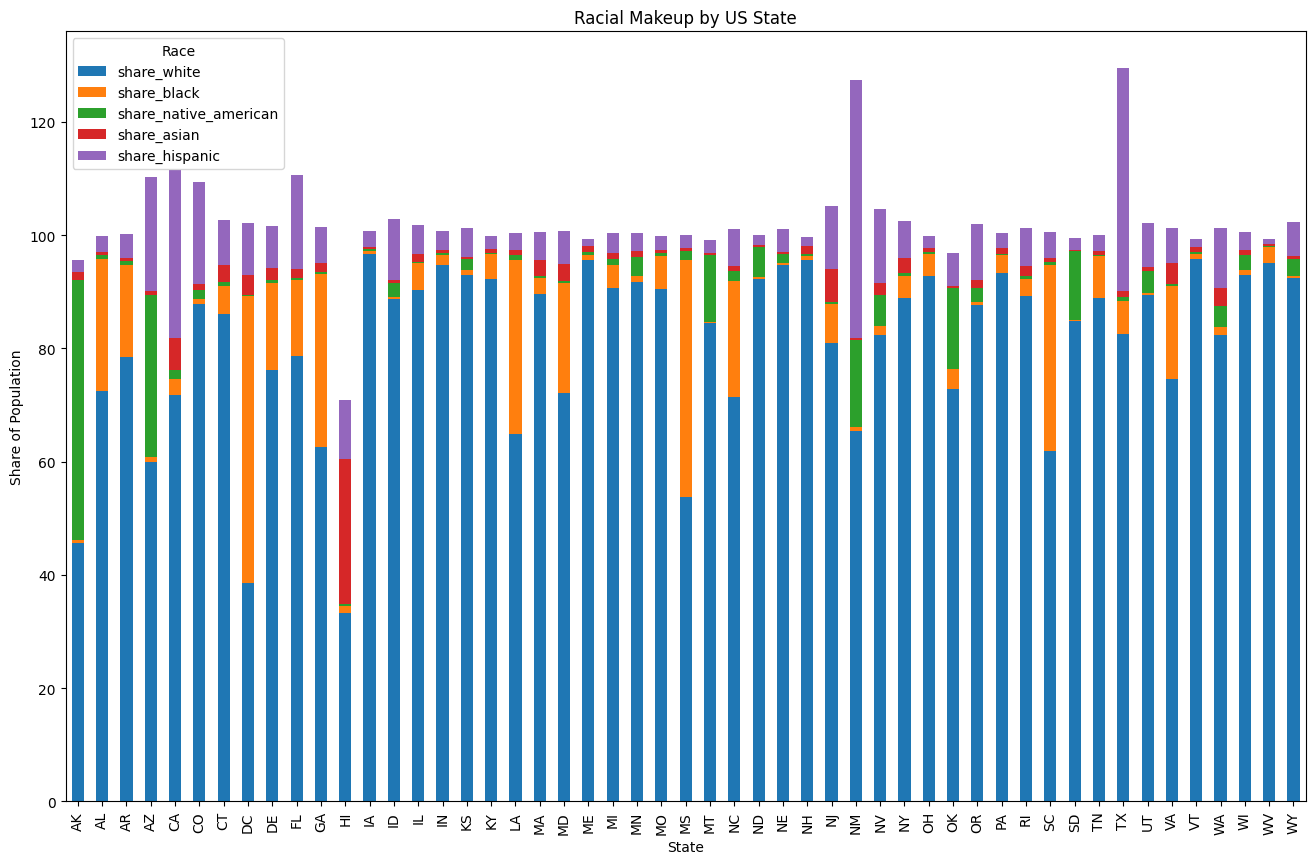

In [24]:
race_by_state.plot(kind='bar', stacked=True, figsize=(16, 10))
plt.title('Racial Makeup by US State')
plt.xlabel('State')
plt.ylabel('Share of Population')
plt.legend(title='Race')
plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [25]:
race_counts = df_fatalities['race'].value_counts()

fig = px.pie(
    values=race_counts.values,
    names=race_counts.index,
    title='Race of People Killed by Police',
    hole=0.4
)

In [26]:
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [27]:
gender_counts = df_fatalities['gender'].value_counts()

fig = px.bar(
    x=gender_counts.index,
    y=gender_counts.values,
    title='Comparison of Police Killings by Gender',
    labels={'x': 'Gender', 'y': 'Number of Deaths'},
    color=gender_counts.index,  # Assign different colors to each bar
    text=gender_counts.values  # Display the count on top of each bar
)

In [28]:
fig.update_traces(textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [29]:
df_fatalities.dropna(subset=['age'], inplace=True)

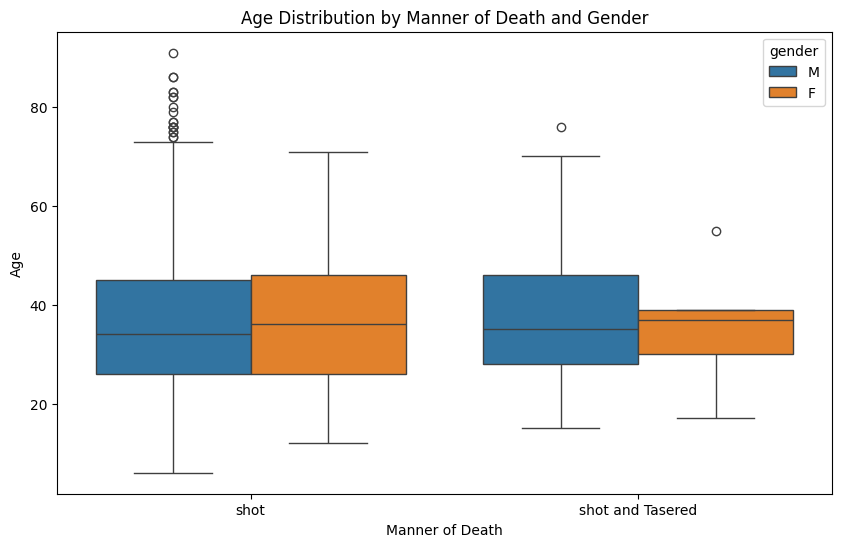

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='manner_of_death', y='age', hue='gender', data=df_fatalities)

plt.title('Age Distribution by Manner of Death and Gender')
plt.xlabel('Manner of Death')
plt.ylabel('Age')

plt.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [31]:
armed_status = df_fatalities['armed'].apply(lambda x: 'Unarmed' if x == 'unarmed' else 'Armed')
armed_percentage = armed_status.value_counts(normalize=True) * 100

In [32]:
weapon_counts = df_fatalities['armed'].value_counts()
top_15_weapons = weapon_counts.head(15)

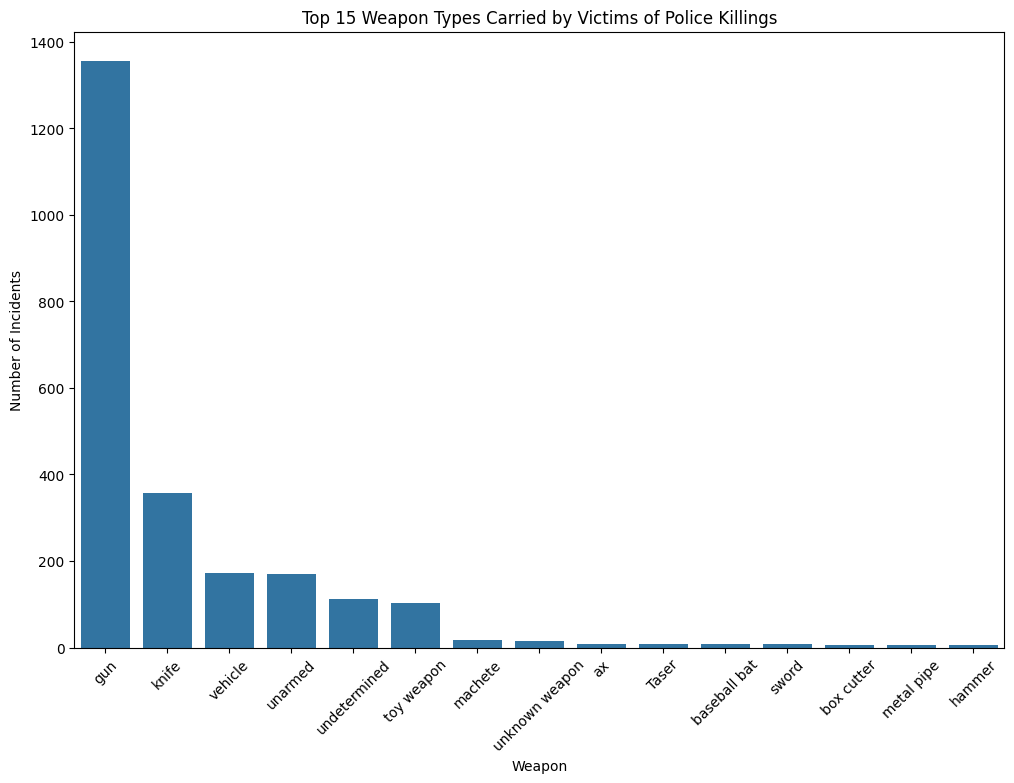

In [33]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_weapons.index, y=top_15_weapons.values)

plt.title('Top 15 Weapon Types Carried by Victims of Police Killings')
plt.xlabel('Weapon')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [34]:
under_25 = df_fatalities[df_fatalities['age'] < 25]
count_under_25 = len(under_25)
total_count = len(df_fatalities)
percentage_under_25 = (count_under_25 / total_count) * 100

print(f"Total number of people killed (with known age): {total_count}")
print(f"Number of people killed under age 25: {count_under_25}")
print(f"Percentage of people killed under age 25: {percentage_under_25:.2f}%")

Total number of people killed (with known age): 2458
Number of people killed under age 25: 450
Percentage of people killed under age 25: 18.31%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

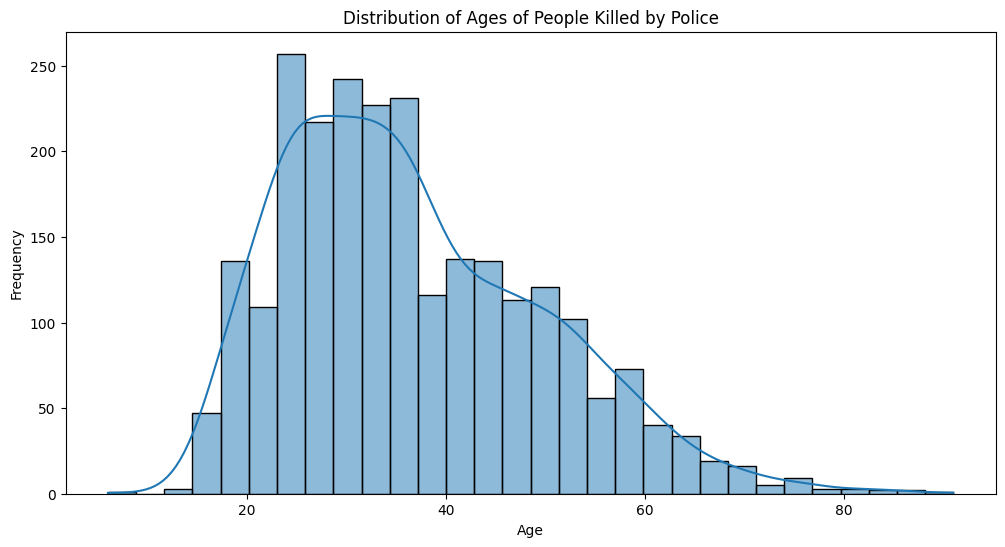

In [35]:
plt.figure(figsize=(12, 6))
sns.histplot(df_fatalities['age'], bins=30, kde=True)

plt.title('Distribution of Ages of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

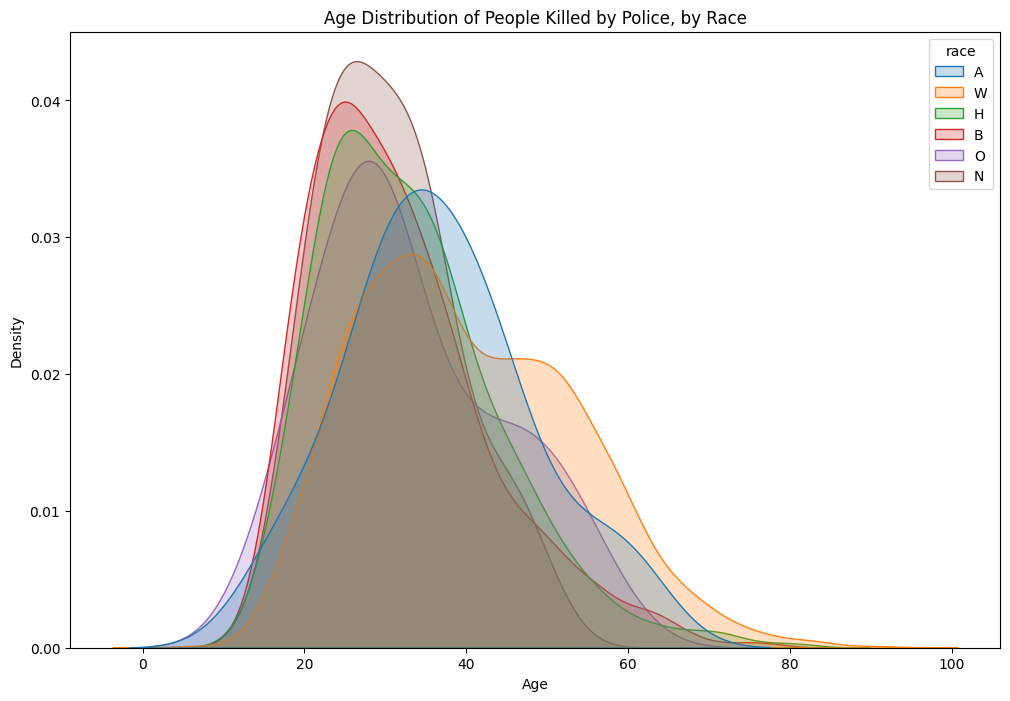

In [36]:
plt.figure(figsize=(12, 8))
sns.kdeplot(
    data=df_fatalities,
    x='age',
    hue='race',
    fill=True,
    common_norm=False
)

plt.title('Age Distribution of People Killed by Police, by Race')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

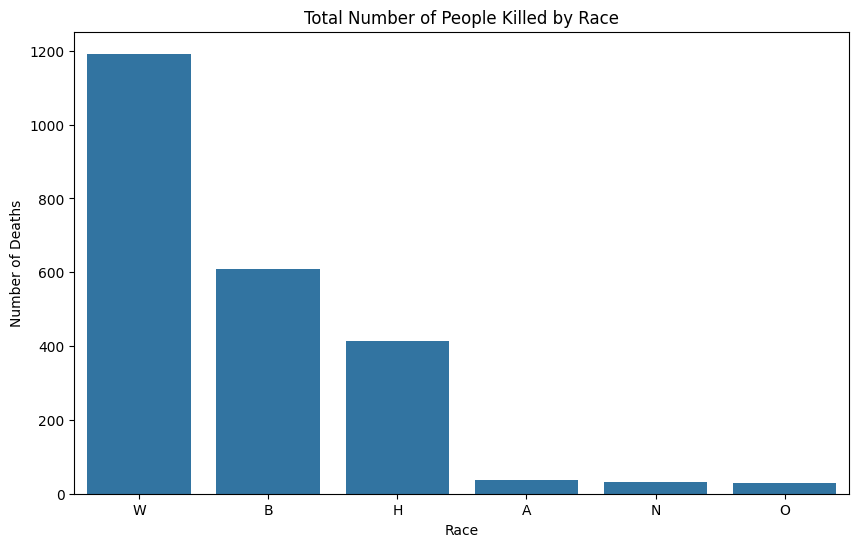

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x=race_counts.index, y=race_counts.values)

plt.title('Total Number of People Killed by Race')
plt.xlabel('Race')
plt.ylabel('Number of Deaths')

plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [38]:
mental_illness_percentage = df_fatalities['signs_of_mental_illness'].value_counts(normalize=True) * 100

In [39]:
fig = px.pie(
    values=mental_illness_percentage.values,
    names=['No Signs of Mental Illness', 'Signs of Mental Illness'], # Custom labels for clarity
    title='Proportion of Victims with Signs of Mental Illness',
    color_discrete_sequence=px.colors.sequential.Blues_r
)

fig.update_traces(textinfo='percent+label', pull=[0, 0.1]) # Emphasize the 'True' slice
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [40]:
top_10_cities = df_fatalities['city'].value_counts().head(10)

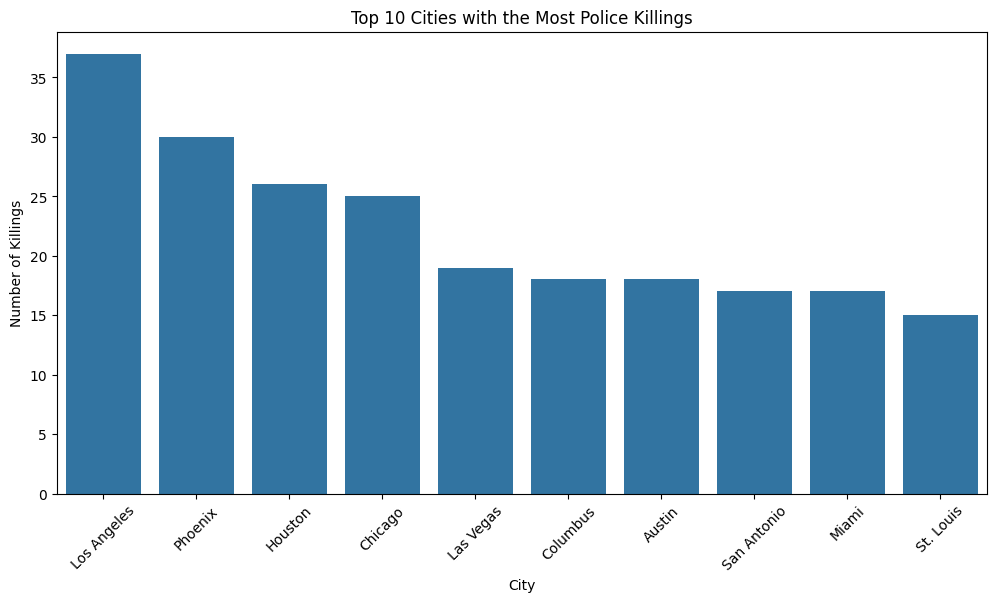

In [41]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_cities.index, y=top_10_cities.values)

plt.title('Top 10 Cities with the Most Police Killings')
plt.xlabel('City')
plt.ylabel('Number of Killings')
plt.xticks(rotation=45)

plt.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [47]:
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv')
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv')

df_fatalities.dropna(subset=['city'], inplace=True)
top_10_cities = df_fatalities['city'].value_counts().head(10).index.tolist()

df_share_race_city['City'] = df_share_race_city['City'].str.replace(r'\s(city|town|CDP|village)$', '', regex=True)
df_share_race_city.rename(columns={'Geographic area': 'state', 'City': 'city'}, inplace=True)

results = []
races = {'W': 'share_white', 'B': 'share_black', 'H': 'share_hispanic', 'A': 'share_asian', 'N': 'share_native_american'}

for city in top_10_cities:
    state = df_fatalities[df_fatalities['city'] == city]['state'].iloc[0]
    city_demographics = df_share_race_city[(df_share_race_city['city'] == city) & (df_share_race_city['state'] == state)]

    if not city_demographics.empty:
        killings_in_city = df_fatalities[df_fatalities['city'] == city]
        killings_distribution = killings_in_city['race'].value_counts(normalize=True)

        for race_code, race_share_col in races.items():
            pop_share_val = pd.to_numeric(city_demographics[race_share_col].iloc[0], errors='coerce')
            pop_share = pop_share_val / 100 if pd.notna(pop_share_val) else 0.0

            victim_share = killings_distribution.get(race_code, 0)

            results.append({'City': city, 'Race': race_code, 'Type': '% of Population', 'Share': pop_share})
            results.append({'City': city, 'Race': race_code, 'Type': '% of Victims', 'Share': victim_share})

df_comparison = pd.DataFrame(results)

if not df_comparison.empty:
    plt.figure(figsize=(20, 10))
    sns.barplot(
        data=df_comparison,
        x='City',
        y='Share',
        hue='Type',
        order=top_10_cities
    )

    plt.title('Disproportionality in Police Killings: Population Share vs. Victim Share in Top 10 Cities', fontsize=18)
    plt.xlabel('City', fontsize=12)
    plt.ylabel('Share (Percentage)', fontsize=12)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.legend(title='Category')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Could not generate a comparison DataFrame. Check for city name mismatches or missing data.")


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x96 in position 25272: invalid start byte

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [48]:
killings_by_state = df_fatalities['state'].value_counts()

In [49]:
fig = px.choropleth(
    locations=killings_by_state.index,
    locationmode="USA-states",
    color=killings_by_state.values,
    color_continuous_scale="Viridis",
    scope="usa",
    title='Total Police Killings by US State',
    labels={'color': 'Number of Killings'}
)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [50]:
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'])

/tmp/ipython-input-2723843298.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [51]:
df_fatalities.set_index('date', inplace=True)

In [52]:
monthly_killings = df_fatalities.resample('M').size()
rolling_avg = monthly_killings.rolling(window=6).mean()

/tmp/ipython-input-3332473761.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



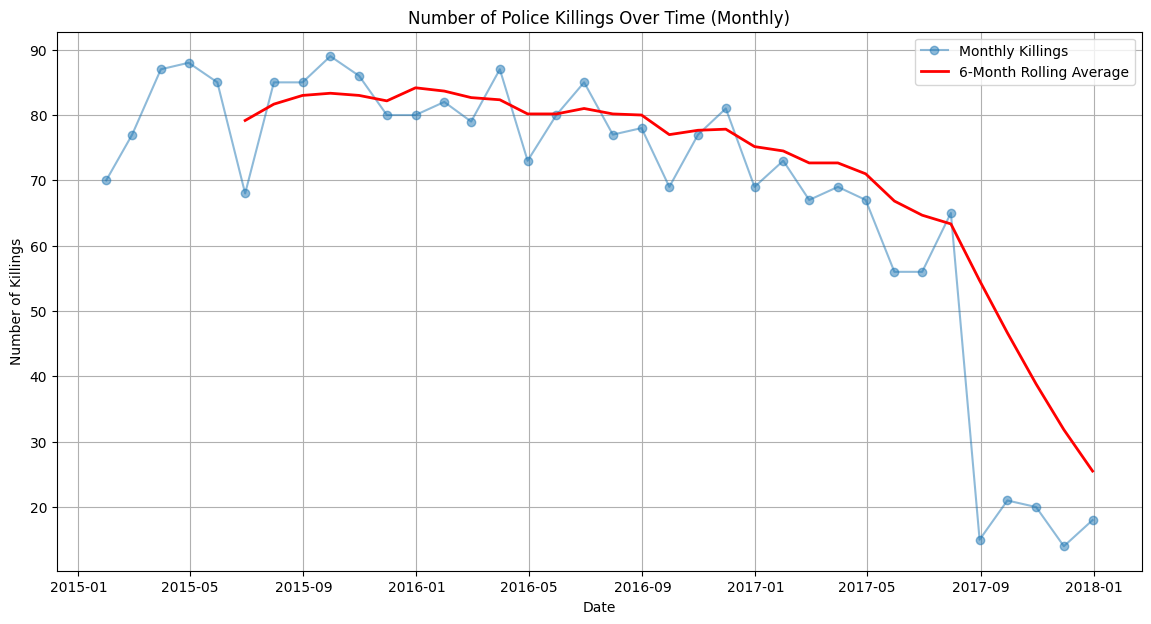

In [53]:
plt.figure(figsize=(14, 7))
plt.plot(monthly_killings.index, monthly_killings.values, marker='o', linestyle='-', alpha=0.5, label='Monthly Killings')
plt.plot(rolling_avg.index, rolling_avg.values, linestyle='-', color='red', linewidth=2, label='6-Month Rolling Average')

plt.title('Number of Police Killings Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Killings')
plt.grid(True)
plt.legend()
plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).